<a href="https://colab.research.google.com/github/OMGItsYutoo/Esercitazioni_ESM/blob/main/colab/Lenet_RGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%reset -f
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

In [ ]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms # Import transforms

# Define transforms with normalization and resize for CIFAR-10
transform = transforms.Compose([
    transforms.Resize((28, 28)), # Resize images to 28x28 to match lenet's expected input
    transforms.ToTensor(), # converts to Tensor and scales to [0, 1]
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # CIFAR-10 mean and std
])

trainval_set=CIFAR10(train=True,download=True,root='./data/',transform=transform)
test_set = CIFAR10(train=False,download=True,root='./data/',transform=transform)
print('Numero immagini training e validation set:', len(trainval_set))
print('Numero immagini test set:', len(test_set))

Numero immagini training e validation set: 50000
Numero immagini test set: 10000


In [ ]:
train_set,val_set=data.random_split(trainval_set,[45000, 5000])

print(f'Training set: {len(train_set)} immagini')
print(f'Validation set: {len(val_set)} immagini')
print(f'Test set: {len(test_set)} immagini')

Training set: 45000 immagini
Validation set: 5000 immagini
Test set: 10000 immagini


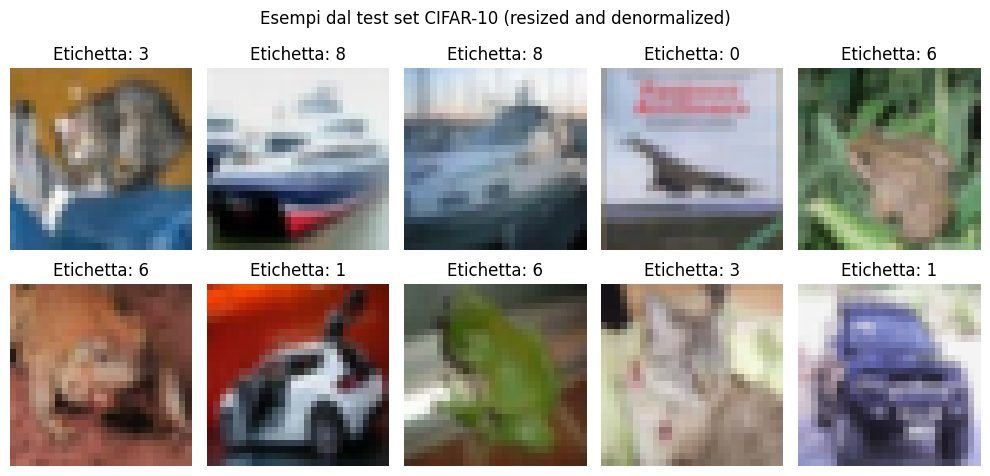

In [ ]:
# Visualizzazione le prima 10 immagini del test set
plt.figure(figsize=(10, 5))

# Define CIFAR-10 mean and std for denormalization
mean = [0.4914, 0.4822, 0.4465]
std = [0.2023, 0.1994, 0.2010]

for index in range(10):
  img, label = test_set[index]
  # img è un tensore float32 con shape (3, H, W) (dopo resize a 28x28), channel-first

  # Denormalize and convert from (C, H, W) to (H, W, C) for matplotlib
  img_np = img.cpu().numpy()
  for i in range(3): # Loop through channels to denormalize
      img_np[i] = img_np[i] * std[i] + mean[i]
  img_np = img_np.transpose((1, 2, 0)) # Permute dimensions to (H, W, C)
  img_np = img_np.clip(0, 1) # Clip values to [0, 1] range for proper display

  plt.subplot(2, 5, index+1)
  plt.imshow(img_np) # imshow handles RGB (H,W,C) automatically
  plt.title(f'Etichetta: {label}')
  plt.axis('off')

plt.suptitle('Esempi dal test set CIFAR-10 (resized and denormalized)') # Aggiorna il titolo
plt.tight_layout() # riduce spazio bianco tra i subplot
plt.show()

In [ ]:
train_loader = data.DataLoader(train_set,batch_size=200, shuffle=True)
val_loader=data.DataLoader(val_set, batch_size=200, shuffle=False)
test_loader = data.DataLoader(test_set, batch_size=200, shuffle=False)

In [ ]:
lenet = nn.Sequential(
  nn.Conv2d(3, 6, kernel_size=5, padding=2),
  # output: 6 x 28 x 28
  nn.ReLU(),
  nn.MaxPool2d(kernel_size=2, stride=2),
  # output: 6 x 14 x 14
  nn.Conv2d(6, 16, kernel_size=5, padding=0), # output: 16 x 10 x 10
  nn.ReLU(),
  nn.MaxPool2d(kernel_size=2, stride=2),
  # output: 16 x 5 x 5
  nn.Flatten(),
  nn.Linear(16 * 5 * 5, 120),
  nn.ReLU(),
  nn.Linear(120, 84),
  nn.ReLU(),
  nn.Linear(84, 10),
  nn.LogSoftmax(dim=1), # restituiamo i logaritmo delle probabilità (logit)
)
print(lenet) # Stampa del sommario dell’architettura

device='cuda:0'
lenet=lenet.to(device)

Sequential(
  (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=400, out_features=120, bias=True)
  (8): ReLU()
  (9): Linear(in_features=120, out_features=84, bias=True)
  (10): ReLU()
  (11): Linear(in_features=84, out_features=10, bias=True)
  (12): LogSoftmax(dim=1)
)


In [ ]:
loss_function = nn.CrossEntropyLoss() # accetterà logit e etichette intere
optimizer = optim.SGD(lenet.parameters(), lr=0.1) # ottimizzatore
num_epochs = 15 # numero di epoche

In [ ]:
for epoch in range(num_epochs):

  # ---- Fase di TRAINING ----
  lenet.train() # abilita comportamenti specifici del training (es. dropout)
  cum_loss = 0.0
  num_images = 0

  for images, labels in train_loader:
    optimizer.zero_grad()
    # (1) azzera i gradienti
    #spostiamo i dati sulla gpu
    images = images.to(device)
    labels = labels.to(device)
    logits = lenet(images)
    # (2) applica la rete
    loss = loss_function(logits, labels) # (3) calcolo del valore di loss
    loss.backward()
    # (4) calcolo gradienti
    optimizer.step()
    # (5) aggiornamento dei pesi
    # Aggiornamento delle statistiche
    cum_loss += loss.item() * images.shape[0] #tensor.item() ritorna il valore in formato base python
    num_images += images.shape[0]

  train_loss = cum_loss / num_images
  print(f'Epoca [{epoch}/{num_epochs}] Loss train: {train_loss:.4f}')

  lenet.eval() # disabilita comportamenti specifici del training
  val_cum_loss = 0.0
  val_cum_correct = 0
  val_num_images = 0

  with torch.no_grad(): # disabilita il calcolo dei gradienti
    for images, labels in val_loader:
      images = images.to(device)
      labels = labels.to(device)
      logits = lenet(images)
      loss = loss_function(logits, labels)
      predicted = torch.argmax(logits, -1) #lungo le righe, l'ultima dimensione
      val_cum_loss += loss.item() * images.shape[0]
      val_cum_correct += torch.sum(predicted==labels).item()
      val_num_images += images.shape[0]

  val_loss = val_cum_loss / val_num_images
  val_acc = val_cum_correct / val_num_images
  print(f'Epoca [{epoch}/{num_epochs}] '
    f'Loss val: {val_loss:.4f} Acc val: {val_acc:.4f}')



Epoca [0/15] Loss train: 1.1561
Epoca [0/15] Loss val: 1.3925 Acc val: 0.5240
Epoca [1/15] Loss train: 1.0731
Epoca [1/15] Loss val: 1.1763 Acc val: 0.5954
Epoca [2/15] Loss train: 1.0114
Epoca [2/15] Loss val: 1.1382 Acc val: 0.6048
Epoca [3/15] Loss train: 0.9741
Epoca [3/15] Loss val: 1.1476 Acc val: 0.6064
Epoca [4/15] Loss train: 0.9352
Epoca [4/15] Loss val: 1.2036 Acc val: 0.5928
Epoca [5/15] Loss train: 0.9064
Epoca [5/15] Loss val: 1.1566 Acc val: 0.6082
Epoca [6/15] Loss train: 0.8755
Epoca [6/15] Loss val: 1.1779 Acc val: 0.6016
Epoca [7/15] Loss train: 0.8343
Epoca [7/15] Loss val: 1.2756 Acc val: 0.5900
Epoca [8/15] Loss train: 0.8095
Epoca [8/15] Loss val: 1.2207 Acc val: 0.6004
Epoca [9/15] Loss train: 0.7928
Epoca [9/15] Loss val: 1.2084 Acc val: 0.6054
Epoca [10/15] Loss train: 0.7677
Epoca [10/15] Loss val: 1.2561 Acc val: 0.5986
Epoca [11/15] Loss train: 0.7406
Epoca [11/15] Loss val: 1.2728 Acc val: 0.6020
Epoca [12/15] Loss train: 0.7181
Epoca [12/15] Loss val: 1.2

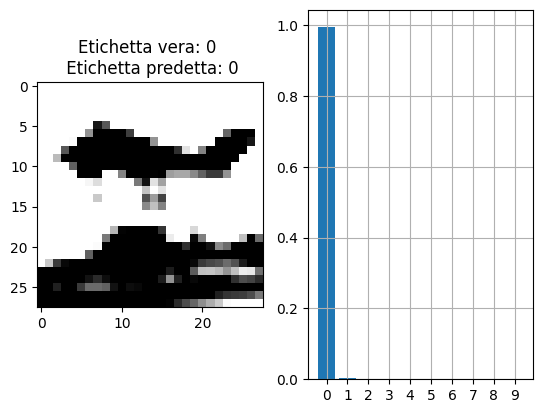

In [ ]:
# Test su una singola immagine
ID = 1500 # indice dell’immaginenel test set
img, label= train_set[ID] # img:tensore (1, 28, 28)
batch_input =img.unsqueeze(0) # aggiungiamo la dimensione batch->(1, 1, 28, 28), necessario perché la rete si aspetta la dimensione del batch come prima dimensione
lenet.eval()

with torch.no_grad():
  batch_input = batch_input.to(device)
  logits =lenet(batch_input)
  probs = torch.softmax(logits, 1) # probabilità per ogniclasse
  pred = torch.argmax(logits, 1).item() # classe predetta

probs = probs[0].cpu().numpy() # conversione da torch (1, 10) a numpy (10,)
img = img[0].cpu().numpy() # conversioneda torch (1, 28, 28) a numpy (28, 28)
plt.figure()
plt.subplot(1,2,1); plt.imshow(img, cmap='gray',clim=[0, 1])
plt.title(f'Etichetta vera: {label} \n Etichetta predetta: {pred}')
plt.subplot(1,2,2); plt.bar(range(10), probs)
plt.xticks(range(10)); plt.grid() # visualizza la griglia
plt.show()

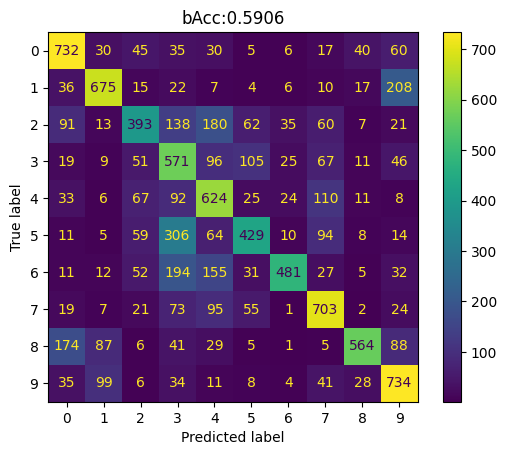

In [ ]:
# Valutazionesull’intero test set
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

lenet.eval()
y_true = []
y_pred = []

with torch.no_grad():
  for images,labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    logits = lenet(images)
    predicted =torch.argmax(logits, 1)
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predicted.cpu().numpy())

bAcc = balanced_accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm).plot() # visualizzala matrice di confusione
plt.title(f'bAcc:{bAcc}')
plt.show()